# Exploración inicial — Dataset Automotriz Tier 1

## Contexto

Análisis exploratorio del dataset de producción de una planta Tier 1 (sintético, generado para portafolio).

## Objetivo

Entender estructura, calidad y patrones generales antes de calcular KPIs industriales (OEE, FPY, Cpk).

## Preguntas que responde esta notebook

1. ¿Cuál es la producción mensual de la planta?
2. ¿Qué máquina produce más volumen? ¿Cuál tiene más scrap?
3. ¿Hay diferencias de productividad entre turnos? *(pendiente)*
## Hallazgos clave

1. **Operadores JR generan 3x más scrap que MASTER.** La certificación 
   es el predictor más fuerte de calidad en esta planta. 
   Inversión en capacitación tiene ROI alto.

2. **M05 tiene scrap alto por concentración de operadores JR**, 
   no por problema mecánico. Redistribuir personal calificado 
   reduciría su scrap rate al nivel de M01-M02.

3. **Turno nocturno T03 genera 57% más scrap relativo** que el 
   vespertino T02. Hipótesis: fatiga humana y menor supervisión.
   Requiere investigación adicional.
---

In [1]:
import pandas as pd
from pathlib import Path


## 1. Definir ruta del dataset
"Definimos la ruta donde están los archivos y verificamos que la carpeta exista antes de continuar."



In [2]:
ruta_datos = Path("../data/raw/dataset_automotriz")
print(ruta_datos.exists())

True


## 2. Verificar contenido de la carpeta
"Listamos los archivos en formato CSV dentro de la carpeta del dataset y contamos cuántos hay."



In [3]:
archivos_csv = list(ruta_datos.glob("*.csv"))
print(f"Encontré {len(archivos_csv)} archivos CSV")



Encontré 11 archivos CSV


In [4]:
for archivo in archivos_csv:
    print(archivo.name)

fact_paros.csv
dim_operadores.csv
fact_defectos.csv
dim_turnos.csv
fact_mantenimiento.csv
fact_produccion.csv
dim_materia_prima.csv
dim_maquinas.csv
dim_proveedores.csv
fact_inspeccion_calidad.csv
dim_productos.csv


#### Lista de archivos dentro de la carpeta dataset_automotriz en formato CSV

## 3. Cargar el CSV de produccion (fact_produccion)
"Cargamos el CSV de producción, convertimos la columna de fechas a formato datetime e imprimimos las dimensiones del DataFrame (filas y columnas)."



In [5]:
produccion = pd.read_csv(ruta_datos / "fact_produccion.csv", parse_dates=["fecha"])
produccion.shape

(12256, 16)

## 4. Inspección inicial del DataFrame 
 Tablas relacionadas: 11 (1 de hechos + 6 dimensionales + 4 de hechos secundarios).
Periodo: mayo 2024 – mayo 2026 (24 meses).
Tabla principal explorada: `fact_produccion` (12,256 registros).


In [6]:
produccion.head(5)

,id_produccion,fecha,id_turno,id_maquina,id_linea,id_operador,id_producto,id_materia_prima,tiempo_planeado_min,tiempo_operativo_min,tiempo_paros_min,velocidad_ppm,piezas_planeadas,piezas_producidas,piezas_buenas,piezas_defectuosas
0,PRD0000001,2024-05-01,T01,M01,L01,OP010,SKU-AUTO-007,MP010,480,471.9,8.1,78.9,599,620,607,13
1,PRD0000002,2024-05-01,T01,M02,L01,OP009,SKU-AUTO-007,MP001,480,474.5,5.5,85.8,652,678,675,3
2,PRD0000003,2024-05-01,T01,M03,L02,OP005,SKU-AUTO-005,MP001,480,453.7,26.3,107.3,815,811,789,22
3,PRD0000004,2024-05-01,T01,M04,L02,OP001,SKU-AUTO-007,MP007,480,470.7,9.3,102.7,780,805,793,12
4,PRD0000005,2024-05-01,T01,M05,L03,OP005,SKU-AUTO-008,MP003,480,444.2,35.8,71.2,540,526,518,8


## 5. Calidad de datos: tipos y nulos
"Revisamos los tipos de dato de cada columna, sus nombres y verificamos si hay valores nulos."




In [7]:
produccion.info()

<class 'pandas.DataFrame'>
RangeIndex: 12256 entries, 0 to 12255
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   id_produccion         12256 non-null  str           
 1   fecha                 12256 non-null  datetime64[us]
 2   id_turno              12256 non-null  str           
 3   id_maquina            12256 non-null  str           
 4   id_linea              12256 non-null  str           
 5   id_operador           12256 non-null  str           
 6   id_producto           12256 non-null  str           
 7   id_materia_prima      12256 non-null  str           
 8   tiempo_planeado_min   12256 non-null  int64         
 9   tiempo_operativo_min  12256 non-null  float64       
 10  tiempo_paros_min      12256 non-null  float64       
 11  velocidad_ppm         12256 non-null  float64       
 12  piezas_planeadas      12256 non-null  int64         
 13  piezas_producidas     12256

#### Informacion de la Tabla de Produccion con 16 columnas, no encontramos Nulos, las fechas estan en formto DateTime

## 6. Estadísticas descriptivas

In [8]:
produccion.describe()

,fecha,tiempo_planeado_min,tiempo_operativo_min,tiempo_paros_min,velocidad_ppm,piezas_planeadas,piezas_producidas,piezas_buenas,piezas_defectuosas
count,12256,12256.0,12256.000000,12256.000000,12256.000000,12256.000000,12256.000000,12256.000000,12256.000000
mean,2025-05-05 16:27:24.908616,480.0,454.555516,25.444484,84.260721,639.880956,637.608029,623.279292,14.328737
min,2024-05-01 00:00:00,480.0,280.000000,0.000000,50.000000,380.000000,335.000000,329.000000,0.000000
25%,2024-11-01 18:00:00,480.0,444.700000,7.300000,72.900000,554.000000,550.000000,539.000000,8.000000
50%,2025-05-06 00:00:00,480.0,462.400000,17.600000,81.600000,620.000000,619.000000,606.000000,13.000000
75%,2025-11-07 00:00:00,480.0,472.700000,35.300000,95.600000,726.000000,719.000000,704.000000,18.000000
max,2026-05-10 00:00:00,480.0,480.000000,200.000000,121.000000,919.000000,967.000000,947.000000,86.000000
std,NaN,0.0,25.779961,25.779961,14.557664,110.638115,115.138031,110.939017,8.606064


### Observaciones

Al comparar Q3 vs máximos hay diferencias grandes, lo que indica 
outliers en varias columnas. En `tiempo_paros_min`, el promedio (25.4) 
es mayor que la mediana (17.6), lo que indica sesgo positivo: algunos 
turnos con paros muy largos jalan el promedio hacia arriba. Se detectaron 
turnos con 0 paros y 0 piezas defectuosas que requieren revisión. 
El máximo de `tiempo_paros_min` es 200 minutos (3h 20min) y el máximo 
de `piezas_defectuosas` es 86 — ambos valores extremos a investigar.

## 7. Producción mensual de la planta

In [9]:
produccion['año_mes'] = produccion['fecha'].dt.to_period('M')
produccion_mensual = produccion.groupby('año_mes')['piezas_producidas'].sum().sort_index(ascending=True)
produccion_mensual.head(12)

año_mes
2024-05    327605
2024-06    313712
2024-07    336164
2024-08    324305
2024-09    323343
2024-10    321010
2024-11    321271
2024-12    328225
2025-01    328807
2025-02    290934
2025-03    324400
2025-04    319875
Freq: M, Name: piezas_producidas, dtype: int64

In [10]:
produccion_mensual.tail(12)

año_mes
2025-06    314620
2025-07    328094
2025-08    325616
2025-09    315999
2025-10    335893
2025-11    322848
2025-12    333230
2026-01    326285
2026-02    289622
2026-03    322137
2026-04    315204
2026-05    101447
Freq: M, Name: piezas_producidas, dtype: int64

### Observaciones — producción mensual

- **Tendencia plana**: la planta produce ~320,000 piezas/mes con poca variación.
- **Febrero 2025 (290,934)** rompe el patrón. Verificamos que tuvo 28 días completos, así que no es por mes corto. Requiere investigación adicional.
- **Mayo 2026 está incompleto** (datos hasta el día 10 del mes). Excluir de comparaciones promedio.

In [11]:
filtrado = produccion[produccion["año_mes"] == pd.Period("2025-02", freq="M")]
filtrado["fecha"].nunique()

28

## 8. Análisis por máquina


In [12]:
analisis_maquinas = produccion.groupby("id_maquina").agg({
    "piezas_producidas" : "sum",
    "piezas_defectuosas" : "sum"
})
analisis_maquinas['porcentaje_scrap'] = analisis_maquinas['piezas_defectuosas'] / analisis_maquinas['piezas_producidas'] * 100
analisis_maquinas['porcentaje_scrap'] = analisis_maquinas['porcentaje_scrap'].round(2)
print(analisis_maquinas.sort_values("piezas_producidas", ascending=False))

            piezas_producidas  piezas_defectuosas  porcentaje_scrap
id_maquina                                                         
M04                   1556738               39395              2.53
M03                   1544471               38777              2.51
M02                   1278264               26464              2.07
M01                   1217203               24822              2.04
M06                   1146529               23588              2.06
M05                   1071319               22567              2.11


### Observaciones — análisis por máquina

- **M03 y M04** lideran en volumen (~1.55M piezas cada una) pero también tienen **mayor % de scrap** (~2.51% y 2.53%).
- **M05** es el  interesante: produce menos volumen (1.07M) y aún así su scrap rate (2.11%) supera al de M01, M02 y M06 (que están ~2.04-2.07%).
- **Hipótesis a validar**: M05 podría tener problemas de calidad independientes del volumen. Posibles causas: operadores menos capacitados, herramienta deteriorada, SKU complejo. Requiere cruzar con tabla `dim_operadores` y `dim_productos`.

## 9. Análisis por turno
- Tabla por turno ordenada de mayor a menor por piezas producidas.

In [13]:
productividad_turno = produccion.groupby("id_turno").agg({
    "piezas_producidas": "sum",
    "piezas_defectuosas": "sum"
})
productividad_turno['porcentaje_scrap'] = (
    productividad_turno['piezas_defectuosas'] / 
    productividad_turno['piezas_producidas']) * 100

print(productividad_turno.round(2).sort_values('piezas_producidas', ascending=False))

          piezas_producidas  piezas_defectuosas  porcentaje_scrap
id_turno                                                         
T03                 2626411               72227              2.75
T01                 2602210               58207              2.24
T02                 2585903               45179              1.75


### Observaciones — análisis por turno

- **Turno T03 (nocturno)** produce el mayor volumen pero también tiene el peor scrap rate (2.75%).
- **Turno T02 (vespertino)** es el más eficiente en calidad (1.75%).
- Diferencia entre T02 y T03: ~57% más de scrap relativo en nocturno. Hipótesis a validar: fatiga humana, menos supervisión, calibraciones diferentes entre turnos.

## Cargamos el CSV de Operadores

In [14]:
operadores = pd.read_csv(ruta_datos / "dim_operadores.csv")
operadores.shape

(20, 5)

## Inspección  del DataFrame 
La Tabla contiene 20 filas y 5 columnas.
Tabla  explorada: `dim_operadores` (20 registros).

In [15]:
operadores.head(10)

,id_operador,nombre_operador,antiguedad_anios,nivel_certificacion,id_turno_habitual
0,OP001,Juan Perez,5.9,SR,T01
1,OP002,Maria Lopez,14.3,JR,T02
2,OP003,Carlos Ramirez,11.1,JR,T01
3,OP004,Ana Torres,9.2,JR,T03
4,OP005,Luis Garcia,2.8,SR,T01
5,OP006,Sofia Hernandez,2.8,SR,T02
6,OP007,Miguel Sanchez,1.3,JR,T01
7,OP008,Laura Martinez,13.1,SR,T02
8,OP009,Roberto Diaz,9.2,SR,T02
9,OP010,Patricia Cruz,10.8,JR,T01


In [16]:
operadores.columns

Index(['id_operador', 'nombre_operador', 'antiguedad_anios',
       'nivel_certificacion', 'id_turno_habitual'],
      dtype='str')

## 10. Enriquecimiento: cruzar producción con operadores

Hasta ahora analicé `fact_produccion` aislada. Pero los hallazgos anteriores
(M05 con scrap alto, turno T03 con más defectos) me piden saber **quién**
operaba esas máquinas en esos turnos.

Para eso necesito cruzar `fact_produccion` con `dim_operadores` usando el JOIN.
La llave común es `id_operador`.

Hago un LEFT JOIN para conservar todas las filas de producción aunque algún
operador no aparezca en `dim_operadores` (caso raro, pero defensivo).

In [17]:
produccion_operadores = produccion.merge( operadores, on='id_operador', how='left')
produccion_operadores.shape
produccion_operadores.head(5)

,id_produccion,fecha,id_turno,id_maquina,id_linea,id_operador,id_producto,id_materia_prima,tiempo_planeado_min,tiempo_operativo_min,...,velocidad_ppm,piezas_planeadas,piezas_producidas,piezas_buenas,piezas_defectuosas,año_mes,nombre_operador,antiguedad_anios,nivel_certificacion,id_turno_habitual
0,PRD0000001,2024-05-01,T01,M01,L01,OP010,SKU-AUTO-007,MP010,480,471.9,...,78.9,599,620,607,13,2024-05,Patricia Cruz,10.8,JR,T01
1,PRD0000002,2024-05-01,T01,M02,L01,OP009,SKU-AUTO-007,MP001,480,474.5,...,85.8,652,678,675,3,2024-05,Roberto Diaz,9.2,SR,T02
2,PRD0000003,2024-05-01,T01,M03,L02,OP005,SKU-AUTO-005,MP001,480,453.7,...,107.3,815,811,789,22,2024-05,Luis Garcia,2.8,SR,T01
3,PRD0000004,2024-05-01,T01,M04,L02,OP001,SKU-AUTO-007,MP007,480,470.7,...,102.7,780,805,793,12,2024-05,Juan Perez,5.9,SR,T01
4,PRD0000005,2024-05-01,T01,M05,L03,OP005,SKU-AUTO-008,MP003,480,444.2,...,71.2,540,526,518,8,2024-05,Luis Garcia,2.8,SR,T01


### Observación

El merge resultó en 12,256 filas × 21 columnas, como esperaba:
- 12,256 filas de `fact_produccion` se preservan (LEFT JOIN).
- 16 columnas originales + 5 nuevas de operadores - 0 columnas perdidas
  (la llave `id_operador` se conserva en el resultado).
- Ahora cada fila de producción tiene nombre del operador, antigüedad,
  certificación y turno habitual.

Se realizo una doble agrupacion de nombre_operador con el nivel_certificacion, para ver si los JR, SR o MASTER son mejores o peores.

## 11. Análisis por operador: nivel de certificación vs scrap


In [18]:
nombre_certificacion=produccion_operadores.groupby("id_operador").agg({
    "nombre_operador": "first",
    "nivel_certificacion": "first",
    "piezas_producidas": "sum",
    "piezas_defectuosas": "sum"
})
nombre_certificacion['porcentaje_scrap'] = (
    nombre_certificacion['piezas_defectuosas'] / 
    nombre_certificacion['piezas_producidas']) * 100
nombre_certificacion.round(2).sort_values('porcentaje_scrap',ascending=False)

,nombre_operador,nivel_certificacion,piezas_producidas,piezas_defectuosas,porcentaje_scrap
id_operador,,,,,
OP012,Diego Morales,JR,417690,17412,4.17
OP004,Ana Torres,JR,456089,15944,3.50
OP013,Andrea Castillo,JR,398849,13685,3.43
OP003,Carlos Ramirez,JR,314002,8897,2.83
OP010,Patricia Cruz,JR,312035,8724,2.80
OP018,Hugo Aguilar,JR,302925,8353,2.76
OP017,Veronica Jimenez,JR,313180,8632,2.76
OP007,Miguel Sanchez,JR,321498,8877,2.76
OP002,Maria Lopez,JR,486360,13233,2.72


### Observaciones — desempeño por operador

- Existe una correlación clara entre **nivel de certificación** y **% de scrap**:
  - MASTER (2 operadores): scrap 0.90-1.08%
  - SR (9 operadores): scrap 1.63-2.08%
  - JR (9 operadores): scrap 2.72-4.17%

- **Diego Morales (JR)** es el operador con peor desempeño individual (4.17% scrap). Caso específico que merece atención.

- **Conclusión**: la formación del operador es uno de los predictores más fuertes de calidad en esta planta. Inversión en capacitación de JRs puede tener ROI alto.

## 12. Análisis enfocado: ¿quién opera M05?

M05 fue identificada como outlier (scrap alto a pesar de bajo volumen).
Investigamos qué operadores están asignados a esta máquina.

In [19]:
tabla_m05 = produccion_operadores[produccion_operadores['id_maquina'] == 'M05']
tabla_m05 = tabla_m05.groupby('id_operador').agg({
    'nombre_operador': 'first',
    'nivel_certificacion': 'first',
    'piezas_producidas': 'sum',
    'piezas_defectuosas': 'sum',
    'id_produccion': 'count'
})
tabla_m05['porcentaje_scrap'] = (
    tabla_m05['piezas_defectuosas'] / 
    tabla_m05['piezas_producidas']) * 100
tabla_m05 = tabla_m05.rename(columns={'id_produccion': 'turnos_trabajados'})
tabla_m05.round(2).sort_values('porcentaje_scrap', ascending=False).head(10)

,nombre_operador,nivel_certificacion,piezas_producidas,piezas_defectuosas,turnos_trabajados,porcentaje_scrap
id_operador,,,,,,
OP012,Diego Morales,JR,69887,2600,133,3.72
OP013,Andrea Castillo,JR,61141,1959,116,3.20
OP004,Ana Torres,JR,58879,1868,111,3.17
OP018,Hugo Aguilar,JR,48332,1249,91,2.58
OP010,Patricia Cruz,JR,31737,820,60,2.58
OP007,Miguel Sanchez,JR,46046,1178,88,2.56
OP017,Veronica Jimenez,JR,45970,1172,87,2.55
OP002,Maria Lopez,JR,71109,1805,136,2.54
OP003,Carlos Ramirez,JR,49748,1226,94,2.46


In [20]:
certificacion_scrap = tabla_m05.groupby('nivel_certificacion')['porcentaje_scrap'].mean().round(2)
certificacion_scrap.sort_values(ascending=False)

nivel_certificacion
JR        2.82
SR        1.63
MASTER    0.92
Name: porcentaje_scrap, dtype: float64

### Conclusión del análisis de M05

En M05, el scrap promedio por nivel de certificación es:
- JR: 2.82%
- SR: 1.63%
- MASTER: 0.92%

La diferencia entre JR y MASTER es de 1.9 puntos porcentuales,
equivalente a triplicar el scrap rate.

**Hallazgo**: M05 no presenta un problema mecánico. Su scrap alto se explica
por la concentración de operadores junior asignados a esa máquina.

**Recomendación**: redistribuir personal calificado entre máquinas para
balancear el scrap rate. Capacitar JRs antes de asignarlos a M05.



## 13. Validación: ¿el turno nocturno concentra más operadores JR?

Hipótesis: T03 tiene más scrap porque concentra más operadores JR.
Validamos contando la distribución de nivel de certificación por turno.

In [21]:
turno_certificacion = produccion_operadores.groupby(['id_turno', 'nivel_certificacion']).agg({
    'id_produccion': 'count'})
turno_certificacion = turno_certificacion.rename(columns={'id_produccion': 'turnos_trabajados'})
turno_certificacion.sort_values(['id_turno', 'nivel_certificacion'], ascending = [True,True]) 

turnos_trabajados
id_turno nivel_certificacion                   
T01      JR                                2269
         MASTER                              70
         SR                                1742
T02      JR                                 959
         MASTER                             732
         SR                                2373
T03      JR                                2002
         MASTER                             647
         SR                                1462

### Hipótesis: ¿T03 fabrica SKUs más complejos?

Eliminamos la hipótesis de "más JRs en T03" con datos — T01 tiene 
más proporción de JR y menos scrap. Investigamos si T03 se concentra 
en productos más difíciles de fabricar.

In [22]:
turno_producto = produccion_operadores.groupby(["id_turno", "id_producto"])["id_produccion"].count().unstack()
turno_producto.head(10)

id_producto,SKU-AUTO-001,SKU-AUTO-002,SKU-AUTO-003,SKU-AUTO-004,SKU-AUTO-005,SKU-AUTO-006,SKU-AUTO-007,SKU-AUTO-008
id_turno,,,,,,,,
T01,758,840,345,350,334,350,651,453
T02,782,785,352,330,334,322,689,470
T03,782,777,316,358,346,360,697,475


### Hipótesis: ¿los JR de T03 tienen menos antigüedad?

La categoría JR es amplia. Un JR con 2 años de experiencia 
no es igual a uno con 2 meses. Verificamos si T03 concentra 
JRs con menos antigüedad promedio.

In [23]:
tabla_jr = produccion_operadores[produccion_operadores['nivel_certificacion'] == 'JR']
tabla_jr = tabla_jr.groupby('id_turno')['antiguedad_anios'].mean()
tabla_jr.head(15)

id_turno
T01     7.440855
T02    13.031804
T03    11.698751
Name: antiguedad_anios, dtype: float64

### Conclusión de la investigación T03

Hipótesis eliminadas con datos:
- T03 no concentra más JR que otros turnos (T01 tiene más).
- T03 no fabrica SKUs más complejos (distribución similar).
- Los JR de T03 no tienen menos antigüedad (T01 tiene JRs más nuevos).

Hipótesis pendiente de verificar:
- ¿Ciertas máquinas operan más en T03 y tienen scrap más alto?

Limitaciones del dataset:
- No hay datos de condiciones ambientales, supervisión ni métodos 
  por turno. Esas hipótesis requieren datos adicionales de planta.

In [24]:
maquinas_turno = produccion_operadores.groupby(['id_turno', 'id_maquina']).agg({
    'piezas_producidas': 'sum',
    'piezas_defectuosas': 'sum'
})
maquinas_turno['porcentaje_scrap'] = (maquinas_turno['piezas_defectuosas'] / maquinas_turno['piezas_producidas'])*100
maquinas_turno.round(2).unstack().head(10)


piezas_producidas                                          \
id_maquina               M01     M02     M03     M04     M05     M06   
id_turno                                                               
T01                   407941  426948  510413  515068  359815  382025   
T02                   402707  415411  517289  515256  354337  380903   
T03                   406555  435905  516769  526414  357167  383601   

           piezas_defectuosas                                   \
id_maquina                M01    M02    M03    M04   M05   M06   
id_turno                                                         
T01                      8154   8707  12772  13259  7420  7895   
T02                      6419   6820  10147   9931  5677  6185   
T03                     10249  10937  15858  16205  9470  9508   

           porcentaje_scrap                                
id_maquina              M01   M02   M03   M04   M05   M06  
id_turno                                                   
T01                    2.00  2.04  2.50  2.57  2.06  2.07  
T02                    1.59  1.64  1.96  1.93  1.60  1.62  
T03                    2.52  2.51  3.07  3.08  2.65  2.48

### Conclusión del análisis T03

El patrón de scrap alto en T03 es consistente en TODAS las máquinas 
(T03 siempre peor, T02 siempre mejor). Esto descarta causas específicas 
de máquina o producto.

Hipótesis investigadas y resultado:
- T03 concentra más JR - falso (T01 tiene más proporción de JR)
- T03 fabrica SKUs más complejos - falso (distribución similar)
- JR de T03 tienen menos antigüedad - falso (T01 tiene JRs más nuevos)
- Ciertas máquinas causan el problema - falso (todas siguen el mismo patrón)

**Conclusión:** causa sistémica del turno nocturno. Factores no 
capturados en este dataset: condiciones ambientales, supervisión, 
fatiga, procedimientos. Requiere investigación directa en planta.

## 14. Visualización: scrap rate por turno

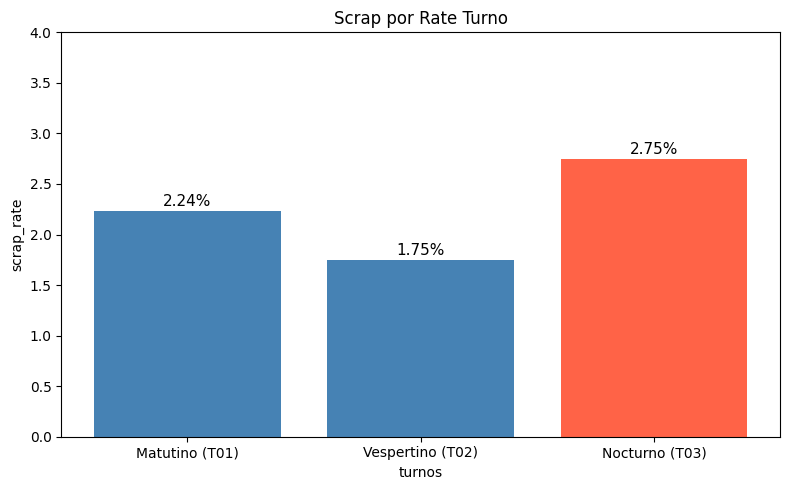

In [25]:

import matplotlib.pyplot as plt
turnos = ["Matutino (T01)", "Vespertino (T02)", "Nocturno (T03)"]
scrap_rates = productividad_turno['porcentaje_scrap'].tolist()
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(turnos, scrap_rates, color=['steelblue', 'steelblue', 'tomato'])

for bar, valor in zip(ax.patches, scrap_rates):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f"{valor:.2f}%",
        ha='center',
        fontsize=11
    )
    
ax.set_title("Scrap por Rate Turno")
ax.set_xlabel("turnos")
ax.set_ylabel("scrap_rate")
ax.set_ylim(0, 4)

plt.tight_layout()
plt.show()

## 15. Cálculo de OEE — Overall Equipment Effectiveness

OEE mide qué tan efectivamente se usa el tiempo productivo disponible.
Se calcula como: Disponibilidad × Rendimiento × Calidad.

Un OEE de 85% se considera world-class en manufactura discreta.
Entre 75-85% es promedio. Menos de 75% indica problemas significativos.

In [26]:
produccion['disponibilidad'] = produccion['tiempo_operativo_min'] / produccion['tiempo_planeado_min']
produccion['rendimiento'] = produccion['piezas_producidas'] / produccion['piezas_planeadas']
produccion['calidad'] = produccion['piezas_buenas'] / produccion['piezas_producidas']
produccion['oee'] = produccion['disponibilidad'] * produccion['rendimiento'] * produccion['calidad']
print(f"OEE promedio de la planta: {produccion['oee'].mean() * 100:.2f}%")

OEE promedio de la planta: 92.62%


### OEE desagregado por máquina y turno

El OEE global de 92.62% es world-class, pero el promedio puede 
esconder variabilidad importante. Desagregamos por máquina y turno.

In [27]:
oee_maquina = produccion.groupby('id_maquina')[['disponibilidad', 'rendimiento', 'calidad', 'oee']].mean() * 100
oee_maquina.round(2).sort_values('oee', ascending=False)

,disponibilidad,rendimiento,calidad,oee
id_maquina,,,,
M05,95.01,100.01,97.90,93.28
M06,94.89,99.89,97.94,93.10
M01,94.86,99.86,97.96,93.06
M02,94.71,99.69,97.93,92.76
M04,94.86,99.85,97.52,92.63
M03,93.85,98.79,97.53,90.85


In [28]:
oee_turno = produccion.groupby('id_turno')[['disponibilidad', 'rendimiento', 'calidad', 'oee']].mean() * 100
oee_turno.round(2).sort_values('oee', ascending=False)

,disponibilidad,rendimiento,calidad,oee
id_turno,,,,
T02,94.64,99.62,98.29,92.96
T01,94.75,99.74,97.81,92.72
T03,94.71,99.69,97.30,92.17


### Corrección: tope de rendimiento al 100%

En algunos turnos, piezas_producidas > piezas_planeadas, lo que genera 
rendimiento > 100% — matemáticamente imposible en OEE estándar.
Se aplica clip(upper=1.0) para corregir.

In [29]:
produccion['disponibilidad'] = produccion['tiempo_operativo_min'] / produccion['tiempo_planeado_min']
produccion['rendimiento'] = (produccion['piezas_producidas'] / produccion['piezas_planeadas']).clip(upper=1.0)
produccion['calidad'] = produccion['piezas_buenas'] / produccion['piezas_producidas']
produccion['oee'] = (
    produccion['disponibilidad'] * 
    produccion['rendimiento'] * 
    produccion['calidad']
)
print(f"OEE promedio corregido: {produccion['oee'].mean() * 100:.2f}%")

OEE promedio corregido: 90.81%


In [30]:
oee_maquina = produccion.groupby('id_maquina')[['disponibilidad', 'rendimiento', 'calidad', 'oee']].mean() * 100
oee_maquina.round(2).sort_values('oee', ascending=False)

,disponibilidad,rendimiento,calidad,oee
id_maquina,,,,
M05,95.01,98.07,97.90,91.41
M06,94.89,97.99,97.94,91.27
M01,94.86,97.95,97.96,91.22
M02,94.71,97.85,97.93,90.98
M04,94.86,97.95,97.52,90.80
M03,93.85,97.07,97.53,89.20


In [31]:
oee_turno = produccion.groupby('id_turno')[['disponibilidad', 'rendimiento', 'calidad', 'oee']].mean() * 100
oee_turno.round(2).sort_values('oee', ascending=False)

,disponibilidad,rendimiento,calidad,oee
id_turno,,,,
T02,94.64,97.77,98.29,91.17
T01,94.75,97.88,97.81,90.93
T03,94.71,97.79,97.30,90.35


### Conclusiones del análisis OEE

- OEE global corregido: 90.81% (world-class, benchmark >85%).
- M03 presenta el OEE más bajo (~90%) con los tres componentes 
  degradados — consistente con problemas de mantenimiento detectados.
- T03 nocturno tiene el OEE más bajo por turno, jalado principalmente 
  por el componente de calidad (mayor scrap).
- El promedio global oculta variabilidad importante entre máquinas 
  y turnos. Siempre desagregar antes de reportar.

In [32]:
oee_mensual = produccion.groupby('año_mes')['oee'].mean()*100
oee_mensual = oee_mensual.round(2)
oee_mensual.sort_values(ascending=False).head(5)

año_mes
2025-10    92.13
2025-05    91.38
2024-06    91.33
2025-11    91.32
2025-12    91.31
Freq: M, Name: oee, dtype: float64

In [33]:
oee_mensual = produccion.groupby('año_mes')['oee'].mean() * 100
oee_mensual = oee_mensual.round(2)
oee_mensual = oee_mensual[oee_mensual.index != pd.Period('2026-05', freq='M')]
meses = oee_mensual.index.astype(str).tolist()
valores_oee = oee_mensual.values.tolist()
oee_mensual.head(5)
print(len(meses))

24


## 16. Tendencia mensual de OEE

Analizamos la evolución del OEE mes a mes para detectar tendencias,
estacionalidad o deterioro en el tiempo. Excluimos mayo 2026 por ser
mes incompleto (datos hasta el día 10).

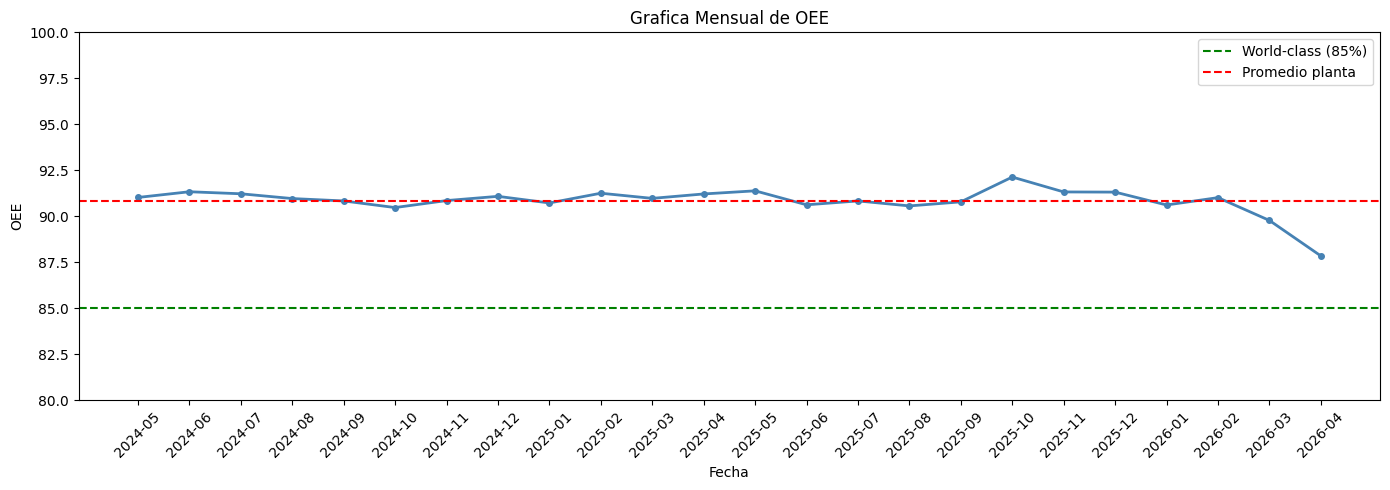

In [34]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(meses, valores_oee, color='steelblue', linewidth=2, marker='o', markersize=4)

ax.axhline(y=85, color='green', linestyle='--', linewidth=1.5, label='World-class (85%)')
ax.axhline(y=oee_mensual.mean(), color='red', linestyle='--', linewidth=1.5, label='Promedio planta')

ax.set_title("Grafica Mensual de OEE")
ax.set_xlabel("Fecha")
ax.set_ylabel("OEE")
ax.set_ylim(80, 100)
ax.tick_params(axis='x', rotation=45)
ax.legend()

plt.tight_layout()
plt.show()

### Observaciones — tendencia mensual OEE

- Tendencia general plana durante los primeros 20 meses (~90.8% promedio).
- Caída visible en los últimos 3 meses (feb-abr 2026). Hipótesis: 
  aumento de scrap en ese periodo afectando el componente de calidad del OEE.
- La planta opera consistentemente ~5 puntos por encima del benchmark 
  world-class (85%), lo que indica operación saludable pero con 
  deterioro reciente que requiere atención.

## 17. OEE por máquina — comparación

Comparamos el OEE promedio de las 6 máquinas para identificar
cuál tiene mayor oportunidad de mejora.

In [35]:
oee_maquina = produccion.groupby('id_maquina')[['disponibilidad','rendimiento','calidad','oee']].mean() * 100
oee_maquina = oee_maquina.round(2).sort_values('oee', ascending=True)
oee_maquina

,disponibilidad,rendimiento,calidad,oee
id_maquina,,,,
M03,93.85,97.07,97.53,89.20
M04,94.86,97.95,97.52,90.80
M02,94.71,97.85,97.93,90.98
M01,94.86,97.95,97.96,91.22
M06,94.89,97.99,97.94,91.27
M05,95.01,98.07,97.90,91.41


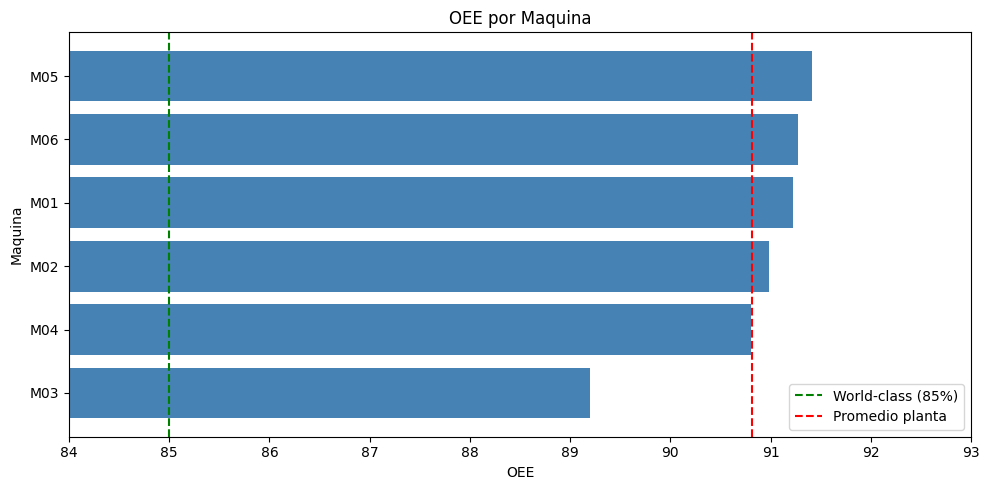

In [36]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(
    oee_maquina.index.tolist(),
    oee_maquina['oee'].tolist(),
    color='steelblue'
)

ax.axvline(x=85, color='green', linestyle='--', linewidth=1.5, label='World-class (85%)')
ax.axvline(x=oee_maquina['oee'].mean(), color='red', linestyle='--', linewidth=1.5, label='Promedio planta')

ax.set_title("OEE por Maquina")
ax.set_xlabel("OEE")
ax.set_ylabel("Maquina")
ax.set_xlim(84, 93)
ax.legend()

plt.tight_layout()
plt.show()

### Observaciones — OEE por máquina

- **M03** es la única máquina por debajo del promedio de la planta (90.81%).
  Su OEE (~90.85%) refleja degradación en los tres componentes.
- Las demás máquinas operan entre 91-93%, todas world-class.
- Nota: el eje X empieza en 84% para resaltar diferencias entre máquinas.
  En escala absoluta (0-100%), las diferencias son pequeñas (~2 puntos).